In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,accuracy_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

In [21]:
df = pd.read_csv("clean_food_dataset.csv")
df.head()

,food_name,protein_g,fat_g,carbohydrates_g,calories_kcal,water_g,fiber_g,calcium_mg,iron_mg,magnesium_mg,potassium_mg,sodium_mg,vitamin_a_ug,vitamin_d_ug,vitamin_c_mg,vitamin_b12_ug,cholesterol_mg,sugar_g
0,misiroti,8.50,5.50,46.50,265.0,34.50,4.5,45.0,2.80,38.0,285.0,285.0,12.0,0.0,4.00,0.0,0.0,2.50
1,escargot,19.99,6.91,2.48,158.0,68.48,0.0,13.0,4.36,310.0,474.0,287.0,35.0,0.0,0.53,62.0,0.0,0.00
2,falafel,8.28,41.19,28.96,514.0,18.73,4.8,86.0,2.31,31.0,259.0,499.0,12.0,0.0,7.30,0.0,0.0,4.52
3,adhirasam,3.20,8.50,52.30,298.0,28.40,1.2,45.0,2.10,22.0,180.0,85.0,8.0,0.0,0.50,0.0,12.0,18.50
4,anarsa,4.10,7.80,58.30,318.0,22.10,0.8,38.0,2.30,18.0,145.0,68.0,4.0,0.0,0.20,0.0,18.0,24.60


In [22]:
X = df[['protein_g','fat_g','carbohydrates_g']]
y = df['calories_kcal']

In [23]:
# Prepare Data for Modeling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, pred_lr))

Linear Regression R2: 0.9015919418754695


In [25]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, pred_dt))

Decision Tree R2: 0.8789494259331458


In [26]:
#Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, pred_rf))

Random Forest R2: 0.9099835892910895


In [27]:
# KNN Model
knn = KNeighborsRegressor()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("KNN R2:", r2_score(y_test, pred_knn))

KNN R2: 0.8528597320039174


In [28]:
# Neural Network
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
nn = MLPRegressor(
    hidden_layer_sizes=(32,16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=3000,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

pred_nn = nn.predict(X_test_scaled)
print("Neural Network R2:", r2_score(y_test, pred_nn))

Neural Network R2: 0.9286011368781741


691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [29]:
import pandas as pd

results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Neural Network"
    ],
    "Accuracy":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_dt),
        r2_score(y_test,pred_rf),
        r2_score(y_test,pred_knn),
        r2_score(y_test,pred_nn)
    ]
})

print(results)

               Model  Accuracy
0  Linear Regression  0.901592
1      Decision Tree  0.878949
2      Random Forest  0.909984
3                KNN  0.852860
4     Neural Network  0.928601


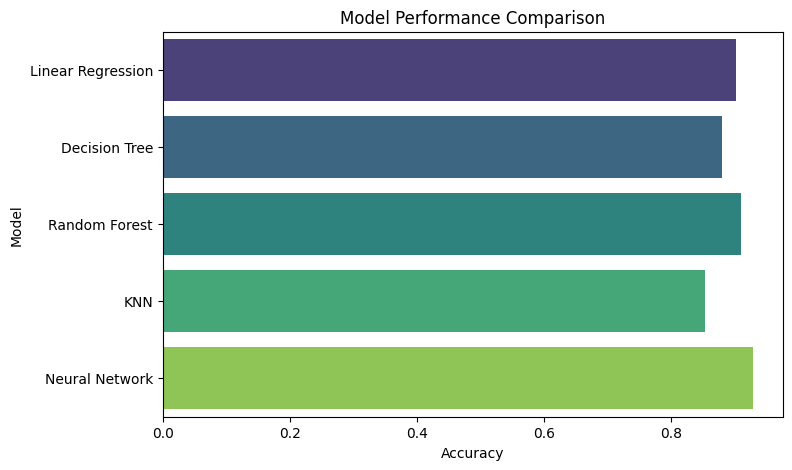

In [30]:

plt.figure(figsize=(8,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=results,
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Model Performance Comparison")

plt.show()

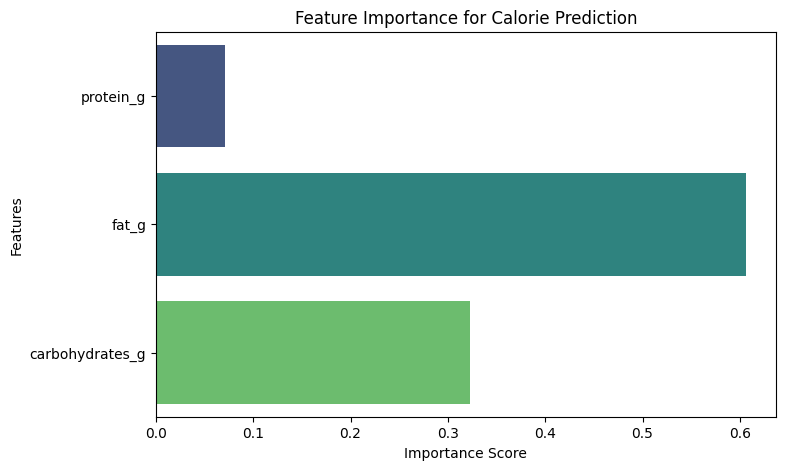

In [31]:
importances = rf.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

sns.barplot(
    x=importances,
    y=features,
    hue=features,
    palette="viridis",
    legend=False
)

plt.title("Feature Importance for Calorie Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

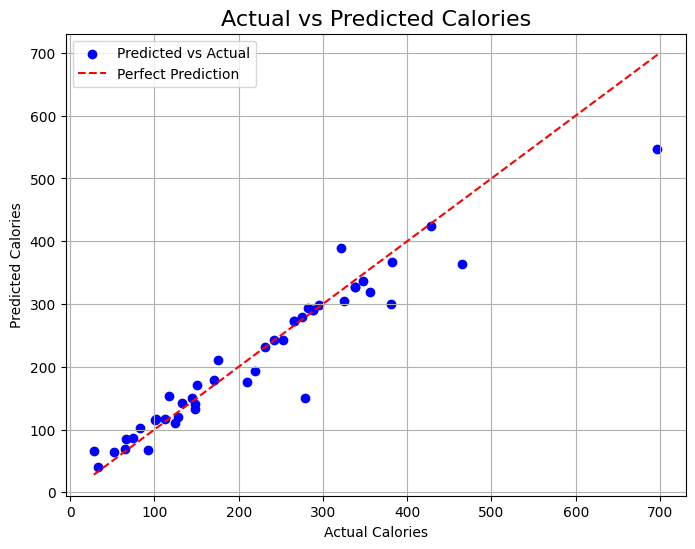

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred_rf,
    color='blue',
    label='Predicted vs Actual'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    label='Perfect Prediction'
)

plt.title("Actual vs Predicted Calories", fontsize=16)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")

plt.legend()
plt.grid(True)

plt.show()

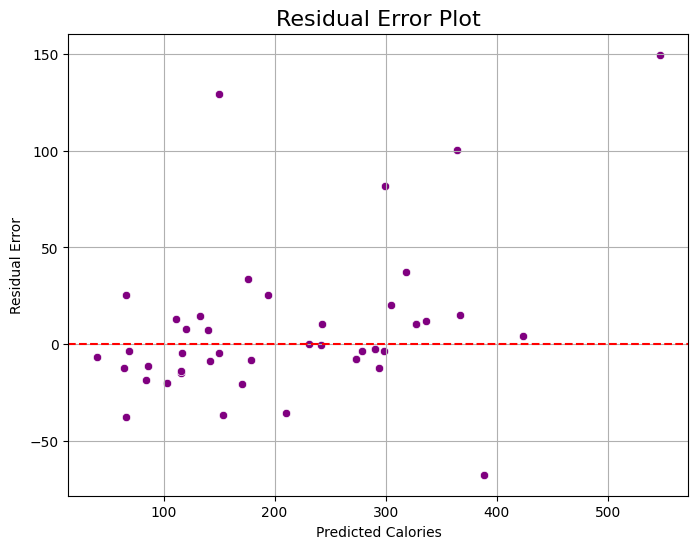

In [33]:
#Residual Error Plot
residuals = y_test - pred_rf

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pred_rf,
    y=residuals,
    color='purple'
)

plt.axhline(0, color='red', linestyle='--')

plt.title("Residual Error Plot", fontsize=16)
plt.xlabel("Predicted Calories")
plt.ylabel("Residual Error")

plt.grid(True)

plt.show()

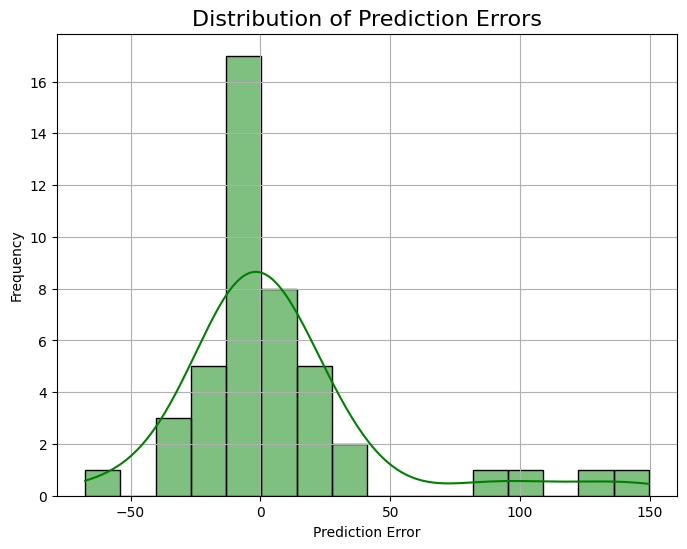

In [34]:
# Error Distribution Plot
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True,
    color='green'
)

plt.title("Distribution of Prediction Errors", fontsize=16)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()